In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker
import math
import pandas as pd
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [55]:
# ----- SET GLOBAL MATPLOTLIB PARAMS -----

dpi = 300

lrgtxt = 11
medtxt = 9
smltxt = 7

plt.rcParams['xtick.labelsize']=smltxt
plt.rcParams['ytick.labelsize']=smltxt

plt.rcParams['axes.titlesize']=lrgtxt
plt.rcParams['axes.labelsize']=medtxt
plt.rcParams["axes.titlepad"]=12
plt.rcParams['axes.linewidth']=1
plt.rcParams["axes.spines.right"]=False
plt.rcParams["axes.spines.top"]=False

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi']= dpi
plt.rcParams['figure.constrained_layout.use'] = True

plt.rcParams['savefig.transparent'] = True

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    # [0.34901962, 0.35686275, 0.49019608],
    [0.19140625, 0.1953125, 0.265625],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# whisker dimensions
whiskspacer = 0.15
whiskpos = -whiskspacer

# plotting parameters
medlw = 1.5 # median linewidth
boxalpha = 0.5 # transparency for boxplot face color
caps = False # don't put caps on the error bars
bwidth = 0.9 # box width
ppad = 0.0085*2 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket

# stats parameters
palpha = 0.05

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# set labels
lbls = ['+/+','-/+']
xlab = 'Scn2a'
ylab = 'percent of assay'

# stats display parameters
pvpct = 0.2

# output directory for figure files
# outdir = 'M:\\scn2a-paper-GWJSNH\\manuscript_v2\\figure_panels'
outdir = 'C:\\Users\\nhogl\\Documents\\Manoli Lab\\2026_scn2a_manuscript\\figure_panels'

# save figures?
savefigs = False

# print stats?
printstats = True

In [56]:
# ----- DEFINE FUNCTIONS -----

def testNormal(input, alpha=0.05):
    if len(input) >= 20:
        #This function is based on D’Agostino and Pearson’s test that combines skew and kurtosis to produce an omnibus test of normality
        results = scipy.stats.normaltest(input) 
        p_values = results.pvalue
        normal_method = "D'Agostino-Pearson test (combined kurtosis + skewness)"
        if p_value > alpha: isnormal = True
        elif p_value <= alpha: isnormal = False
    else: 
        #For n<20, we have to rely on a Monte Carlo approach to test skew and kurtosis (kurtosistest is only valid n>=20) 
        rvs = lambda size: scipy.stats.norm.rvs(size=size, random_state=np.random.default_rng())
        skew_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.skew, vectorized=True)
        kurtosis_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.kurtosis, vectorized=True)
        p_values = [skew_results.pvalue, kurtosis_results.pvalue]
        normal_method = "Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)"
        # data is only treated as normal if it has both normal skew and kurtosis
        if p_values[0] > 0.05 and p_values[1] > alpha: isnormal = True
        else: isnormal = False
    return isnormal, p_values, normal_method

def decide_pval_text(pval,palpha):

    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'

    return ptxt

def add_pair_to_plot_box(df,grp1,grp2,statkey,ax,col1,col2,startx,dotdist,errdist,psdist,whiskpos,ptxt):

    # -- GROUP 1 --
    tdf = df[df['GT']==grp1].copy().reset_index(drop=True)
    tcol=col1

    max1 = np.max(tdf[statkey])
    min1 = np.min(tdf[statkey])
    
    # plot group 1 dots
    ax.plot(np.zeros(tdf.shape[0])+startx+dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot group 1 boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(tdf[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # -- GROUP 2 --    
    tdf = df[df['GT']==grp2].copy().reset_index(drop=True)
    tcol=col2

    max2 = np.max(tdf[statkey])
    min2 = np.min(tdf[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(tdf.shape[0])+startx+psdist-dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(tdf[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    return np.min([min1,min2]), np.max([max1,max2])

def make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur):
    # organize and sum total behavior time
    sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
    sums['fraction']=sums['duration']/assaydur*100
    
    # keep track of details across multiple plots
    axes = []
    maxes = []
    mins = []
    ptxts = []
    figs = []
    fnames = []
    
    # do a loop over sexes to make sure they have the same axis parameters
    for sex in sexes:
        if sex=='male':
            sexlet = 'M'
            cols = mcols
        else:
            sexlet = 'F'
            cols = fcols
    
        fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg' # generate file name for output plot
        print(fname)
        fnames.append(fname)
    
        # filter to given sex
        fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)
    
        # -- stats --
        # log transform data to check for normality
        # check for normality
        # print results of normality check
        isnorms = []
        for gt in ['WT','Het']:
            isnormal,p_values,normal_method = testNormal(np.log(fsums[fsums['GT']==gt]['duration']))
            isnorms.append(isnormal)
            print(f'Normality test results for {gt} {sex}: {isnormal} by {normal_method}, p = {p_values}')
        # check whether normal distribution holds
        if all(isnorms):
            # check for equal variance
            bartres = scipy.stats.bartlett(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))
            eqvar = bartres.pvalue>0.05
            # run ttest on log transformed data
            statres = scipy.stats.ttest_ind(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']),equal_var=eqvar)
        else:
            statres = scipy.stats.mannwhitneyu(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))
    
        if printstats:
            print(statres) 
        pval = statres.pvalue
        ptxt = decide_pval_text(pval,palpha)
        ptxts.append(ptxt)
    
        # make figure
        figsz = (1.25,2) # total size of figure
        fig, ax = plt.subplots(figsize=figsz)
        axes.append(ax)
        figs.append(fig)
    
        # make plot
        mn,mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
        maxes.append(mx)
        mins.append(mn)
        # fig.text(0.64,-0.065,'Scn2a',ha='center',size=lrgtxt)
        # plt.text(0.5,-0.065,'Scn2a',ha='center',size=lrgtxt)

    
    for ax,ptxt,fig,fname in zip(axes,ptxts,figs,fnames):
        ax.set_yscale('log')
        
        # calculations for scaling min, max, and pval stuff
        tmx = np.max(maxes)
        tmn = np.min(mins)
        axmin = tmn-0.2*tmn
        axmax = 1.7*tmx
        ax.set_ylim([axmin,axmax])
        
        # display statistical test results
        axrange = axmax-axmin
        ppad = axrange*pvpct
        y, h = tmx + ppad, ppad
        px1 = start
        px2 = start+psdist
        ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
        # make height pad factor to pull test bracket up
        ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=medtxt)
        
        # labeling
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([start,start+psdist],labels=lbls,fontsize=medtxt)
        ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.get_yaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
        labels = []
        for tick in ax.get_yticks():
            if tick>=1:
                label = f'{int(tick)}'
            else:
                label = f'{tick: .1f}'
            labels.append(label)
        ax.set_yticklabels(labels)
        ax.tick_params(axis='x', which='both',length=0)
        ax.set_xlabel(xlab,)
        ax.set_ylabel(ylab)
    
        if savefigs:
            fig.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [4]:
# ----- LOAD AND FILTER DATA -----
assay = 'introduction'
assaydur = 1800
data = pd.read_csv(os.path.join('..','all_annotations.csv')).drop(labels=['Unnamed: 0','id'],axis=1)
data = data[data.assay==assay].copy().reset_index(drop=True)

boxDotPlot_introduction_Investigate_Sniff_female.svg
Normality test results for WT female: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.6864), np.float64(0.0882)]
Normality test results for Het female: False by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.0044), np.float64(0.0262)]
MannwhitneyuResult(statistic=np.float64(89.0), pvalue=np.float64(0.8374719604535413))
boxDotPlot_introduction_Investigate_Sniff_male.svg
Normality test results for WT male: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.226), np.float64(0.4628)]
Normality test results for Het male: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.5806), np.float64(0.4742)]
TtestResult(statistic=np.float64(-2.2703074248535295), pvalue=np.float64(0.0320657004144601), df=np.float64(25.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_3932\3222351243.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_3932\3222351243.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


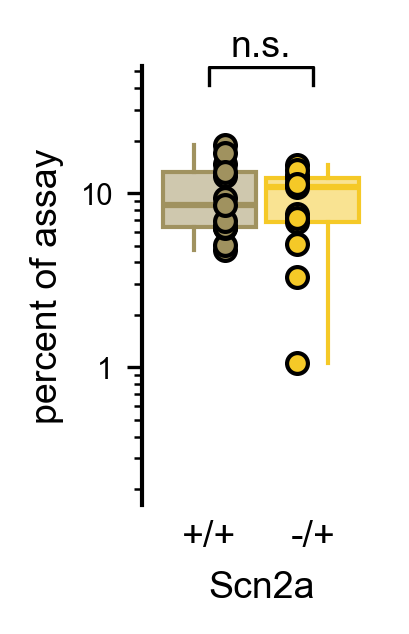

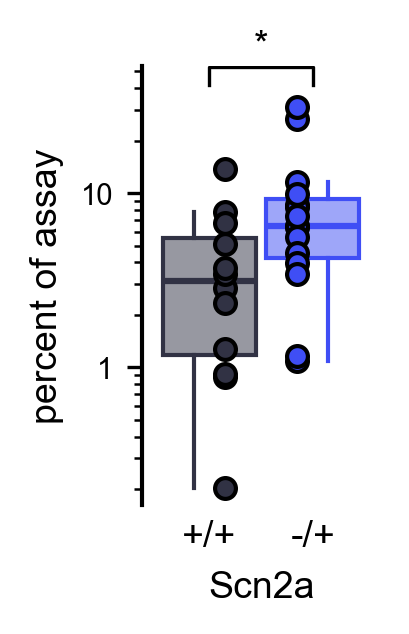

In [57]:
# ----- PLOT INVESTIGATIVE BEHAVIORS INTRO, MALE AND FEMALE -----

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
# i = 2
# blist = [behavs[i]]
blist = behavs[0:2]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur)

boxDotPlot_introduction_Huddle_female.svg
Normality test results for WT female: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.1242), np.float64(0.7408)]
Normality test results for Het female: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.0726), np.float64(0.3288)]
TtestResult(statistic=np.float64(0.7607359086681381), pvalue=np.float64(0.45454377226170006), df=np.float64(23.0))
boxDotPlot_introduction_Huddle_male.svg
Normality test results for WT male: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.4226), np.float64(0.4214)]
Normality test results for Het male: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.4908), np.float64(0.4176)]
TtestResult(statistic=np.float64(-3.4715396010668487), pvalue=np.float64(0.0033805795166330465), df=np.float64(15.12636104907601))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_3932\3222351243.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_3932\3222351243.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


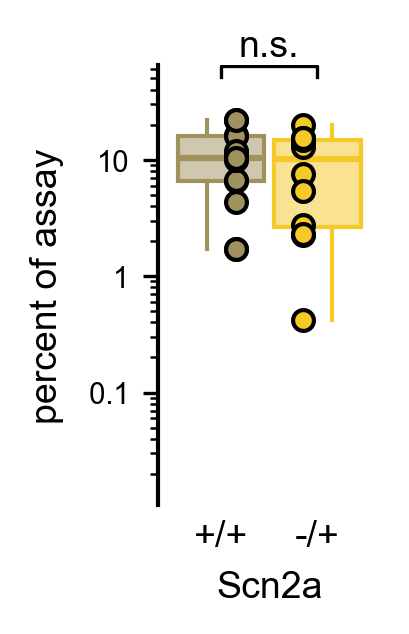

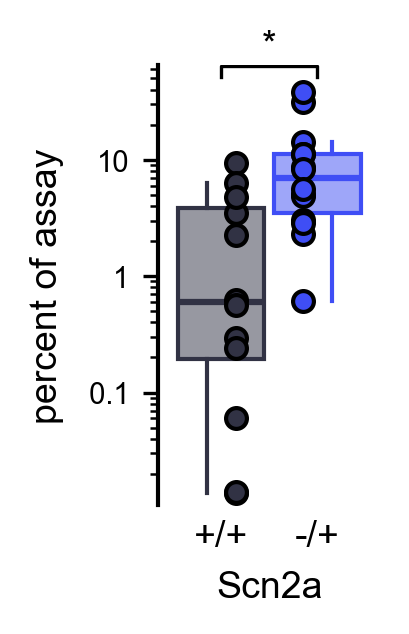

In [58]:
# ----- PLOT AFFILIATIVE BEHAVIORS INTRO, MALE AND FEMALE -----

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
blist = [behavs[2]]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur)

In [8]:
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur*100

In [11]:
sums_male = sums[sums['sex']=='M'].copy().reset_index(drop=True)

In [14]:
sums_male_WT = sums_male[sums_male['GT']=='WT'].copy().reset_index(drop=True)

In [15]:
sums_male_WT

,pair_tag,GT,sex,duration,fraction
0,Pair18,WT,M,40.503,2.250167
1,Pair19,WT,M,168.212,9.345111
2,Pair38,WT,M,62.986,3.499222
3,Pair39,WT,M,5.252,0.291778
4,Pair40,WT,M,11.167,0.620389
5,Pair41,WT,M,0.244,0.013556
6,Pair43,WT,M,113.622,6.312333
7,Pair47,WT,M,85.967,4.775944
8,Pair49,WT,M,10.244,0.569111
9,Pair51,WT,M,4.337,0.240944


boxDotPlot_introduction_Investigate_Sniff_female.svg
Normality test results for WT female: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.8998), np.float64(0.0772)]
Normality test results for Het female: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.478), np.float64(0.3846)]
TtestResult(statistic=np.float64(0.7186808753483414), pvalue=np.float64(0.4792767414722734), df=np.float64(24.0))
boxDotPlot_introduction_Investigate_Sniff_male.svg
Normality test results for WT male: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.9338), np.float64(0.929)]
Normality test results for Het male: True by Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness), p = [np.float64(0.9902), np.float64(0.5186)]
TtestResult(statistic=np.float64(-2.2703074248535295), pvalue=np.float64(0.0320657004144601), df=np.float64(25.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_21912\3786568505.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_21912\3786568505.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


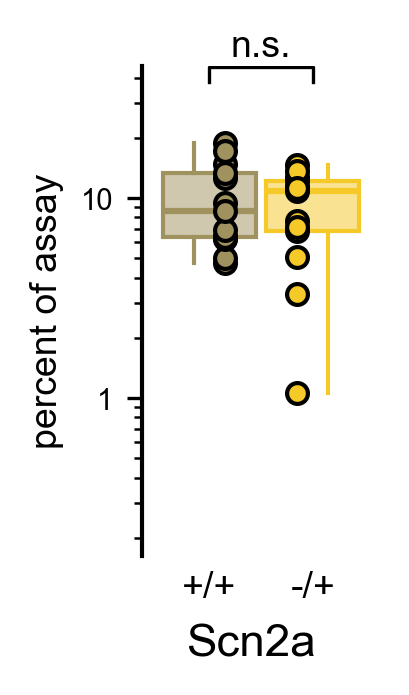

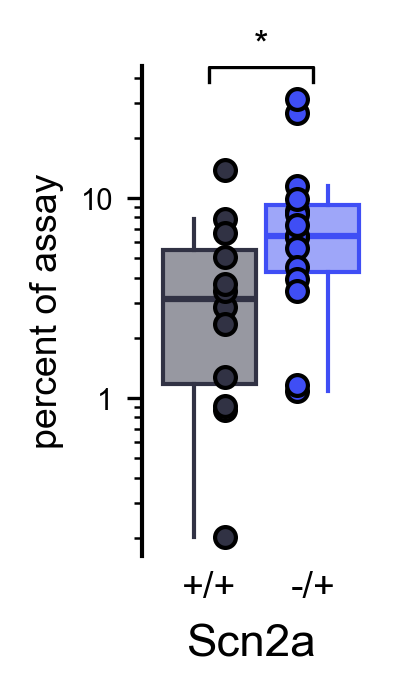

In [14]:
# ----- CONSTRUCTION ZONE: ADJUST PLOT DISPLAY PARAMETERS -----

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

pvpct = 0.15

# filter to relevant single behavior
# i = 2
# blist = [behavs[i]]
blist = behavs[0:2]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

# organize and sum total behavior time
sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
sums['fraction']=sums['duration']/assaydur*100

# keep track of details across multiple plots
axes = []
maxes = []
mins = []
ptxts = []
figs = []
fnames = []

# do a loop over sexes to make sure they have the same axis parameters
for sex in sexes:
    if sex=='male':
        sexlet = 'M'
        cols = mcols
    else:
        sexlet = 'F'
        cols = fcols

    fname = f'boxDotPlot_{assay}_{bstr}{sex}.svg' # generate file name for output plot
    print(fname)
    fnames.append(fname)

    # filter to given sex
    fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)

    # -- stats --
    # log transform data to check for normality
    # check for normality
    # print results of normality check
    isnorms = []
    for gt in ['WT','Het']:
        isnormal,p_values,normal_method = testNormal(np.log(fsums[fsums['GT']==gt]['duration']))
        isnorms.append(isnormal)
        print(f'Normality test results for {gt} {sex}: {isnormal} by {normal_method}, p = {p_values}')
    # check whether normal distribution holds
    if all(isnorms):
        # check for equal variance
        bartres = scipy.stats.bartlett(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))
        eqvar = bartres.pvalue>0.05
        # run ttest on log transformed data
        statres = scipy.stats.ttest_ind(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']),equal_var=eqvar)
    else:
        statres = scipy.stats.mannwhitneyu(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))

    print(statres) 
    pval = statres.pvalue
    ptxt = decide_pval_text(pval,palpha)
    ptxts.append(ptxt)

    # make figure
    figsz = (1.25,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    axes.append(ax)
    figs.append(fig)

    # make plot
    mn,mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',ax,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt)
    maxes.append(mx)
    mins.append(mn)
    fig.text(0.625,-0.065,'Scn2a',ha='center',size=lrgtxt)

for ax,ptxt,fig,fname in zip(axes,ptxts,figs,fnames):
    ax.set_yscale('log')
    
    # calculations for scaling min, max, and pval stuff
    tmx = np.max(maxes)
    tmn = np.min(mins)
    axmin = tmn-0.2*tmn
    axmax = 1.45*tmx
    ax.set_ylim([axmin,axmax])
    
    # display statistical test results
    axrange = axmax-axmin
    ppad = axrange*pvpct
    y, h = tmx + ppad, ppad
    px1 = start
    px2 = start+psdist
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
    # make height pad factor to pull test bracket up
    ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=medtxt)
    
    # labeling
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([start,start+psdist],labels=lbls,fontsize=medtxt)
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.get_yaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
    labels = []
    for tick in ax.get_yticks():
        label = f'{int(tick)}'
        labels.append(label)
    ax.set_yticklabels(labels)
    ax.tick_params(axis='x', which='both',length=0)
    ax.set_xlabel(xlab,fontsize=10)
    ax.set_ylabel(ylab)

    if savefigs:
        fig.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [13]:
scipy.stats.boxcox(fsums[fsums['GT']==gt]['duration'])[0]

array([2.5246284 , 2.37539904, 2.60570739, 2.44439103, 2.38951163,
       2.64531534, 2.57772439, 2.62999435, 2.58753654, 2.43994492,
       2.44437385, 2.46226769, 2.50599257])

In [9]:
maxes

[np.float64(0.18857277777777776), np.float64(0.31404166666666666)]